In [20]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

from keras import models
from keras import layers

train_images = train_images.reshape(train_images.shape[0], 28 * 28).astype("float32")
test_images = test_images.reshape(test_images.shape[0], 28 * 28).astype("float32")

train_images /= 255
test_images /= 255

from keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

network = models.Sequential()
network.add(layers.Dense(512, activation="relu", input_shape=(28 * 28,)))
network.add(layers.Dense(10, activation="softmax"))

network.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])

history = network.fit(train_images, train_labels, epochs=5, batch_size=128, validation_data=(test_images, test_labels))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8766 - loss: 0.4326 - val_accuracy: 0.9658 - val_loss: 0.1180
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9661 - loss: 0.1140 - val_accuracy: 0.9731 - val_loss: 0.0888
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9800 - loss: 0.0701 - val_accuracy: 0.9732 - val_loss: 0.0857
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9846 - loss: 0.0496 - val_accuracy: 0.9801 - val_loss: 0.0637
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9886 - loss: 0.0379 - val_accuracy: 0.9777 - val_loss: 0.0720


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9746 - loss: 0.0835
test_acc: 0.9776999950408936


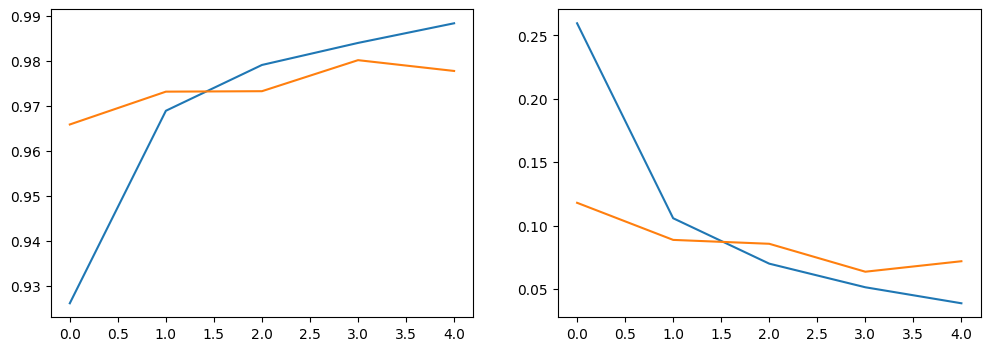

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")


test_loss, test_acc = network.evaluate(test_images, test_labels)

print("test_acc:", test_acc)